In [2]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
!pip install --upgrade scikit-learn==1.6.1


Defaulting to user installation because normal site-packages is not writeable


In [4]:
df = pd.read_excel(r"C:\Users\computer inn\Desktop\G7. Hydrogen-production-from-plastic-waste.xlsx")

In [5]:
df.head()

,PE/PP,Steam/Plastic,Tg (C ),NG/Plastics,P-NH3 (bar),NH3 (kg/h)
0,85.848164,1.530988,983.333333,0.615571,140,324.165562
1,85.848164,1.530988,866.666667,0.615571,140,323.830279
2,85.848164,1.530988,1100.000000,0.615571,140,323.712460
3,85.848164,1.530988,983.333333,0.615571,110,322.830759
4,85.848164,1.530988,983.333333,0.550166,140,322.782416


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PE/PP          928 non-null    float64
 1   Steam/Plastic  928 non-null    float64
 2   Tg (C )        928 non-null    float64
 3   NG/Plastics    928 non-null    float64
 4   P-NH3 (bar)    928 non-null    int64  
 5   NH3 (kg/h)     928 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 43.6 KB


In [7]:
df.describe()

,PE/PP,Steam/Plastic,Tg (C ),NG/Plastics,P-NH3 (bar),NH3 (kg/h)
count,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000
mean,22.366847,1.780076,930.657328,0.523006,93.448276,276.711682
std,36.993805,0.582824,129.707390,0.069967,33.754068,25.280670
min,0.010059,0.995926,750.000000,0.418289,50.000000,227.339420
25%,0.505072,1.527086,866.666667,0.483527,50.000000,253.591125
50%,1.956438,1.530988,983.333333,0.548764,80.000000,274.731108
75%,85.848164,2.063505,1100.000000,0.614002,110.000000,301.201201
max,85.848165,2.596023,1100.000000,0.615571,140.000000,324.165562


In [8]:
print(df.isnull().sum())

PE/PP            0
Steam/Plastic    0
Tg (C )          0
NG/Plastics      0
P-NH3 (bar)      0
NH3 (kg/h)       0
dtype: int64


In [9]:
numeric_cols=['PE/PP','Steam/Plastic','Tg (C )','NG/Plastics','P-NH3 (bar)','NH3 (kg/h)']

from sklearn.preprocessing import MinMaxScaler , StandardScaler
scaler_norm = MinMaxScaler()
df[numeric_cols]=scaler_norm.fit_transform(df[numeric_cols])

print("After Normalization:")
print(df.head())

# Standardization (mean=0, std=1)
scaler_std=StandardScaler()
df[numeric_cols]=scaler_std.fit_transform(df[numeric_cols])

print("[bold]After Standardization:[/bold]")
print(df.head())


After Normalization:
   PE/PP  Steam/Plastic   Tg (C )  NG/Plastics  P-NH3 (bar)  NH3 (kg/h)
0    1.0       0.334393  0.666667     1.000000     1.000000    1.000000
1    1.0       0.334393  0.333333     1.000000     1.000000    0.996537
2    1.0       0.334393  1.000000     1.000000     1.000000    0.995320
3    1.0       0.334393  0.666667     1.000000     0.666667    0.986214
4    1.0       0.334393  0.666667     0.668472     1.000000    0.985715
[bold]After Standardization:[/bold]
      PE/PP  Steam/Plastic   Tg (C )  NG/Plastics  P-NH3 (bar)  NH3 (kg/h)
0  1.716924      -0.427612  0.406333     1.323694     1.379888    1.878094
1  1.716924      -0.427612 -0.493612     1.323694     1.379888    1.864824
2  1.716924      -0.427612  1.306279     1.323694     1.379888    1.860161
3  1.716924      -0.427612  0.406333     1.323694     0.490627    1.825266
4  1.716924      -0.427612  0.406333     0.388399     1.379888    1.823353


In [10]:
print(df.columns)

Index(['PE/PP', 'Steam/Plastic', 'Tg (C )', 'NG/Plastics', 'P-NH3 (bar)',
       'NH3 (kg/h)'],
      dtype='object')


In [11]:
X=df.drop(columns=['NH3 (kg/h)'])
y=df['NH3 (kg/h)']

In [12]:
from sklearn.model_selection import train_test_split
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

=== K-Nearest Neighbors (KNN) Regressor with 10-Fold Cross Validation ===
Computation Time      : 0.31 seconds
Mean R2 Score         : 0.9390
Standard Deviation    : 0.0192

Regression Metrics:
MSE                   : 0.0597
RMSE                  : 0.2443
R2 Score              : 0.9403


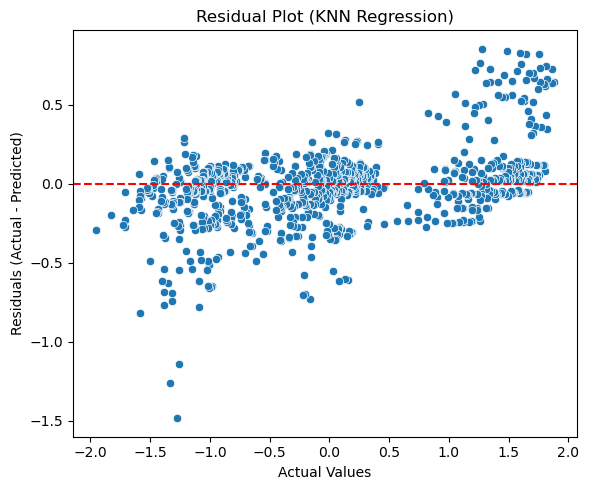

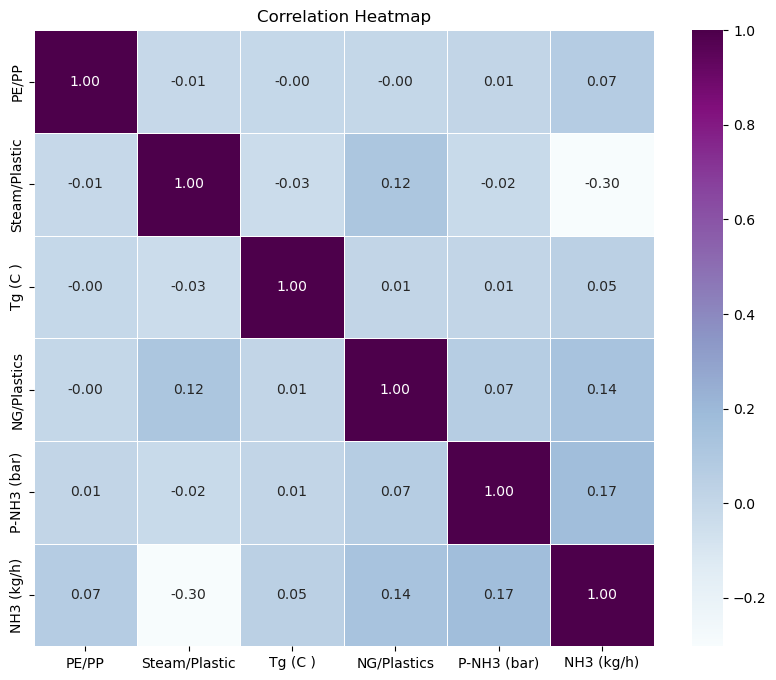

In [13]:
knn_model = KNeighborsRegressor(n_neighbors=5)
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

#Step:6 Start timing
start_time=time.time()

#Step:7 Cross Validiation
cv_scores = cross_val_score(knn_model, X, y, cv=kfold, scoring='r2')
mean_r2 = cv_scores.mean()
std_r2 = cv_scores.std()

#Step:8 Predictions for evaluation
y_pred_cv = cross_val_predict(knn_model, X, y,cv=kfold)

# Step:9 End Timing
runtime=time.time() -start_time


# === Results ===
print("=== K-Nearest Neighbors (KNN) Regressor with 10-Fold Cross Validation ===")
print(f"Computation Time      : {runtime:.2f} seconds")
print(f"Mean R2 Score         : {mean_r2:.4f}")
print(f"Standard Deviation    : {std_r2:.4f}")

print("\nRegression Metrics:")
print(f"MSE                   : {mean_squared_error(y, y_pred_cv):.4f}")
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE                  : {rmse:.4f}")
print(f"R2 Score              : {r2_score(y, y_pred_cv):.4f}")

# Residuals
residuals = y - y_pred_cv

plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (KNN Regression)")
plt.tight_layout()
plt.show()

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)   # numeric_only avoids errors if non-numeric columns exist

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="BuPu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


=== Linear Regression with 10-Fold Cross Validation ===
Computation Time      : 0.26 seconds
Mean R2 Score         : 0.1189
Standard Deviation    : 0.0613

Regression Metrics:
MSE                   : 0.8642
RMSE                  : 0.9296
R2 Score              : 0.1358


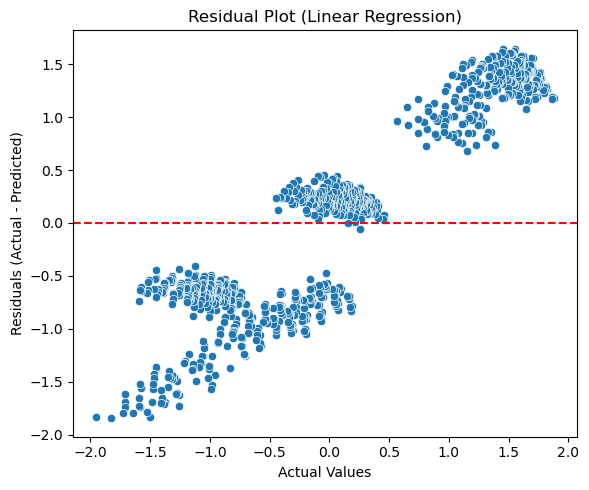

In [14]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

#Step:6 Start timing
start_time=time.time()

#Step:7 Cross Validiation
cv_scores = cross_val_score(lr_model, X, y, cv=kfold, scoring='r2')
mean_r2 = cv_scores.mean()
std_r2 = cv_scores.std()

#Step:8 Predictions for evaluation
y_pred_cv = cross_val_predict(lr_model, X, y,cv=kfold)

# Step:9 End Timing
runtime=time.time() -start_time


# === Results ===
print("=== Linear Regression with 10-Fold Cross Validation ===")
print(f"Computation Time      : {runtime:.2f} seconds")
print(f"Mean R2 Score         : {mean_r2:.4f}")
print(f"Standard Deviation    : {std_r2:.4f}")

print("\nRegression Metrics:")
print(f"MSE                   : {mean_squared_error(y, y_pred_cv):.4f}")
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE                  : {rmse:.4f}")
print(f"R2 Score              : {r2_score(y, y_pred_cv):.4f}")

# Residuals
residuals = y - y_pred_cv

plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.tight_layout()
plt.show()

=== Decision Tree Regressor with 10-Fold Cross Validation ===
Computation Time      : 0.29 seconds
Mean R2 Score         : 0.9986
Standard Deviation    : 0.0008

Regression Metrics:
MSE                   : 0.0014
RMSE                  : 0.0377
R2 Score              : 0.9986


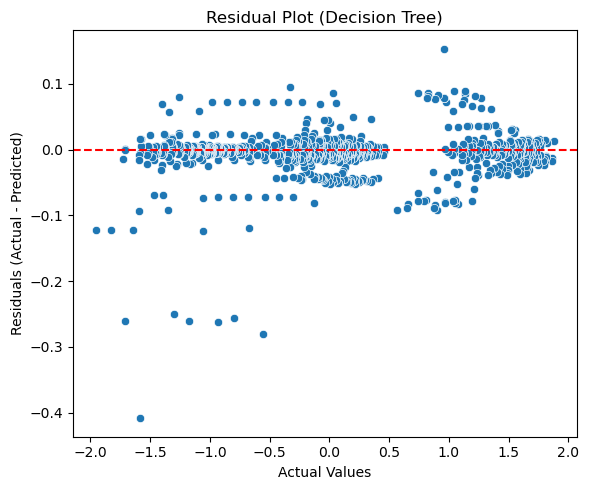

In [16]:
from sklearn.tree import DecisionTreeRegressor
dec_tree_model = DecisionTreeRegressor(random_state=42)
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

#Step:6 Start timing
start_time=time.time()

#Step:7 Cross Validiation
cv_scores = cross_val_score(dec_tree_model, X, y, cv=kfold, scoring='r2')
mean_r2 = cv_scores.mean()
std_r2 = cv_scores.std()

#Step:8 Predictions for evaluation
y_pred_cv = cross_val_predict(dec_tree_model, X, y,cv=kfold)

# Step:9 End Timing
runtime=time.time() -start_time


# === Results ===
print("=== Decision Tree Regressor with 10-Fold Cross Validation ===")
print(f"Computation Time      : {runtime:.2f} seconds")
print(f"Mean R2 Score         : {mean_r2:.4f}")
print(f"Standard Deviation    : {std_r2:.4f}")

print("\nRegression Metrics:")
print(f"MSE                   : {mean_squared_error(y, y_pred_cv):.4f}")
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE                  : {rmse:.4f}")
print(f"R2 Score              : {r2_score(y, y_pred_cv):.4f}")

# Residuals
residuals = y - y_pred_cv

plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Decision Tree)")
plt.tight_layout()
plt.show()


=== Random Forest Regressor with 10-Fold Cross Validation ===
Computation Time      : 11.92 seconds
Mean R2 Score         : 0.9991
Standard Deviation    : 0.0004

Regression Metrics:
MSE                   : 0.0009
RMSE                  : 0.0304
R2 Score              : 0.9991


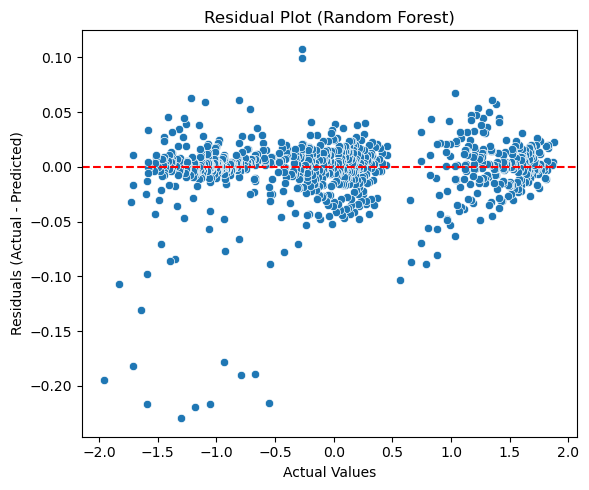

In [17]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

#Step:6 Start timing
start_time=time.time()

#Step:7 Cross Validiation
cv_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='r2')
mean_r2 = cv_scores.mean()
std_r2 = cv_scores.std()

#Step:8 Predictions for evaluation
y_pred_cv = cross_val_predict(rf_model, X, y,cv=kfold)

# Step:9 End Timing
runtime=time.time() -start_time


# === Results ===
print("=== Random Forest Regressor with 10-Fold Cross Validation ===")
print(f"Computation Time      : {runtime:.2f} seconds")
print(f"Mean R2 Score         : {mean_r2:.4f}")
print(f"Standard Deviation    : {std_r2:.4f}")

print("\nRegression Metrics:")
print(f"MSE                   : {mean_squared_error(y, y_pred_cv):.4f}")
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE                  : {rmse:.4f}")
print(f"R2 Score              : {r2_score(y, y_pred_cv):.4f}")

# Residuals
residuals = y - y_pred_cv

plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Random Forest)")
plt.tight_layout()
plt.show()


=== Gradient Boosting Regressor with 10-Fold Cross Validation ===
Computation Time      : 4.32 seconds
Mean R2 Score         : 0.9991
Standard Deviation    : 0.0002

Regression Metrics:
MSE                   : 0.0009
RMSE                  : 0.0299
R2 Score              : 0.9991


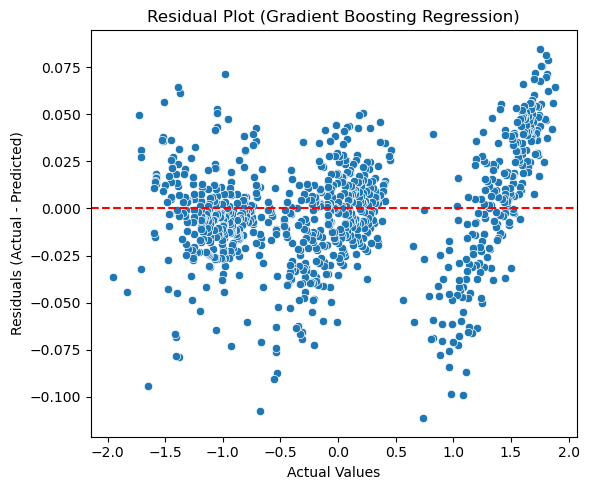

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,   
    learning_rate=0.1,  
    max_depth=3,       
    random_state=0
)
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

#Step:6 Start timing
start_time=time.time()

#Step:7 Cross Validiation
cv_scores = cross_val_score(gb_model, X, y, cv=kfold, scoring='r2')
mean_r2 = cv_scores.mean()
std_r2 = cv_scores.std()

#Step:8 Predictions for evaluation
y_pred_cv = cross_val_predict(gb_model, X, y,cv=kfold)

# Step:9 End Timing
runtime=time.time() -start_time


# === Results ===
print("=== Gradient Boosting Regressor with 10-Fold Cross Validation ===")
print(f"Computation Time      : {runtime:.2f} seconds")
print(f"Mean R2 Score         : {mean_r2:.4f}")
print(f"Standard Deviation    : {std_r2:.4f}")

print("\nRegression Metrics:")
print(f"MSE                   : {mean_squared_error(y, y_pred_cv):.4f}")
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE                  : {rmse:.4f}")
print(f"R2 Score              : {r2_score(y, y_pred_cv):.4f}")

# Residuals
residuals = y - y_pred_cv

plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Gradient Boosting Regression)")
plt.tight_layout()
plt.show()


In [19]:
import pickle

# Save KNN
with open("Plasti2Hydro_KNN_model.pkl", "wb") as file:
    pickle.dump(knn_model, file)

# Save Linear Regression
with open("Plasti2Hydro_LR_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

# Save Gradient Boosting
with open("Plasti2Hydro_GB_model.pkl", "wb") as file:
    pickle.dump(gb_model, file)

# Save Random Forest
with open("Plasti2Hydro_RF_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

# Save Decision Tree
with open("Plasti2Hydro_DT_model.pkl", "wb") as file:
    pickle.dump(dec_tree_model, file)

print("✅ All models saved successfully (KNN, LR, GB, RF, DT)")


✅ All models saved successfully (KNN, LR, GB, RF, DT)
